In [1]:
import importlib
import solver
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

In [ ]:
# Initial Conditions: split into two regions by initial discontinuity
WL = {"rho":1.0,   "u":0.0, "p":100000.0}
WR = {"rho":0.125, "u":0.0, "p":10000.0}

XMIN = -10.0
XMAX = 10.0
N = 50
CFL = 0.4
GAMMA = 1.4 # air
T_END = 0.01
UMAX=374.17


In [3]:
# import reference solution
variables = ["density", "entropy", "mach", "massflux", "pressure", "velocity"]
dfs = []
folder = "exact/"
for i,var in enumerate(variables):
    file_name = f"{var}.exa"
    df = pd.read_csv(
        folder + file_name,
        sep=r"\s+",
        skiprows=1,
        names=["x", var],
        engine="python"
    )
    if i>0:
        df = df.drop(columns=["x"])
    dfs.append(df)
exact_df = pd.concat(dfs, axis=1)
exact_df["total_energy"] = (
    exact_df["pressure"] / ((GAMMA - 1)*exact_df["density"])
    + 0.5 *exact_df["velocity"]**2
)


In [ ]:
importlib.reload(solver)
Physics, Solver = solver.Physics, solver.Solver

solver_sw = Solver(
    scheme="sw",
    xmin=XMIN,
    xmax=XMAX,
    N=N,
    wl=WL,
    wr=WR,
    CFL=CFL,
    Umax = UMAX
)

solver_vl = Solver(
    scheme="vl",
    xmin=XMIN,
    xmax=XMAX,
    N=N,
    wl=WL,
    wr=WR,
    CFL=CFL,
    Umax = UMAX
)


results_dict = {
    "Stager-Warming": solver_sw.run(0.0, 0.01),
    "Van Leer": solver_vl.run(0.0, 0.01)
}


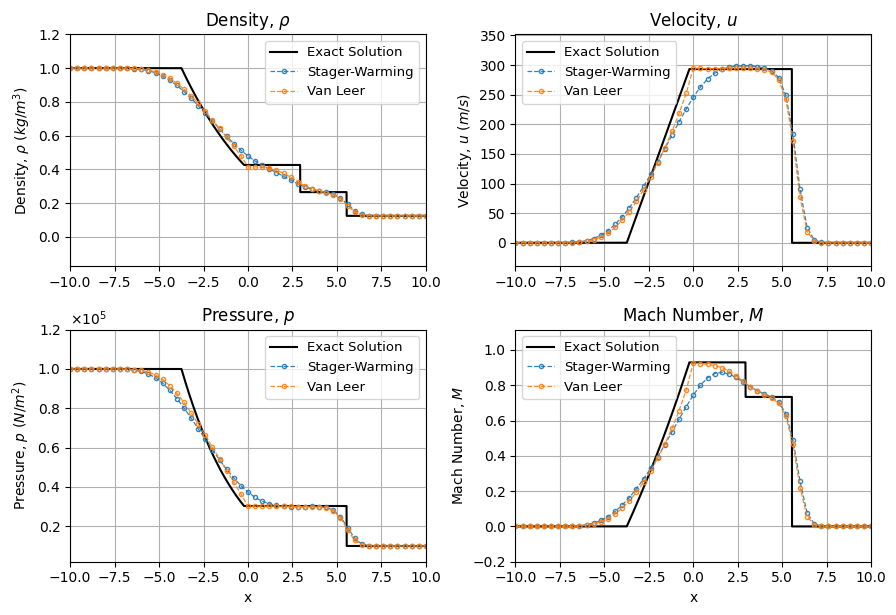

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9,6.25))
axes = axes.flatten()
y_labels = [r"Density, $\rho~(kg/m^3)$", r"Velocity, $u~(m/s)$", r"Pressure, $p~(N/m^2)$", r"Mach Number, $M$"]
columns_to_plot = ["density", "velocity", "pressure", "mach"]
titles = [r"Density, $\rho$", r"Velocity, $u$", r"Pressure, $p$", r"Mach Number, $M$"]
for i, var in enumerate(columns_to_plot):
    ax = axes[i]
    ax.plot(exact_df["x"], exact_df[var], label="Exact Solution", color="black")
    
    if var == 'velocity':
        ax.set_ylim(-40, exact_df[var].max()*1.2)
    else:
        ax.set_ylim(exact_df[var].min()*0.2-0.2, exact_df[var].max()*1.2)
    for scheme, results_df in results_dict.items():
        if var in results_df.columns:
            ax.plot(results_df["x"], results_df[var], 'o--', markersize=3, markerfacecolor=f'None',linewidth=0.9, label=scheme, alpha=0.9,)
    ax.set_title(titles[i])
    ax.legend(fontsize=9.5, loc='best')
    ax.grid(zorder=0)
    if exact_df[var].max() > 1e3:
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylabel(y_labels[i])
    if i>1:
        ax.set_xlabel("x")
    
# fig.suptitle("Steger-Warming Scheme")
fig.tight_layout()
